In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 3. A portfolio with a risky and a safe asset

## Question 1

### 3.1.1

In [35]:
from PortfolioModel import PortfolioModelClass
import numpy as np

# We create the portfolio model with the default parameters from the exam
model = PortfolioModelClass()
print(model)

# We draw the random shocks and turn them into gross returns R_t
R = model.draw_returns()

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026


### 3.1.2

In [36]:
par = model.par
logR = np.log(R)

# We compare the simulated mean and standard deviation of log R with mu and sigma
print(f'mean of log R = {logR.mean():.4f}, mu    = {par.mu:.4f}')
print(f'std of log R  = {logR.std():.4f}, sigma = {par.sigma:.4f}')

# We compare the simulated mean of R with the closed-form mean of a log-normal variable
print(f'mean of R          = {R.mean():.4f}')
print(f'exp(mu + 0.5*sig2) = {np.exp(par.mu + 0.5*par.sigma**2):.4f}')

mean of log R = 0.0500, mu    = 0.0500
std of log R  = 0.2000, sigma = 0.2000
mean of R          = 1.0725
exp(mu + 0.5*sig2) = 1.0725


We see that the mean of $R_t$ and $\exp(\mu+\frac{1}{2}\sigma^2)$ are equal, which is the expected result. 
$\log(R_t)$ is normal by construction, and for a normal variable, the mean of $\exp(X)$ is always $\exp(\mu +\frac{1}{2}\sigma^2)$ rather than $\exp(\mu)$, since $\exp$ is convex. The simulated mean lining up with the formula just confirms the returns are being drawn correctly.

### 3.1.3

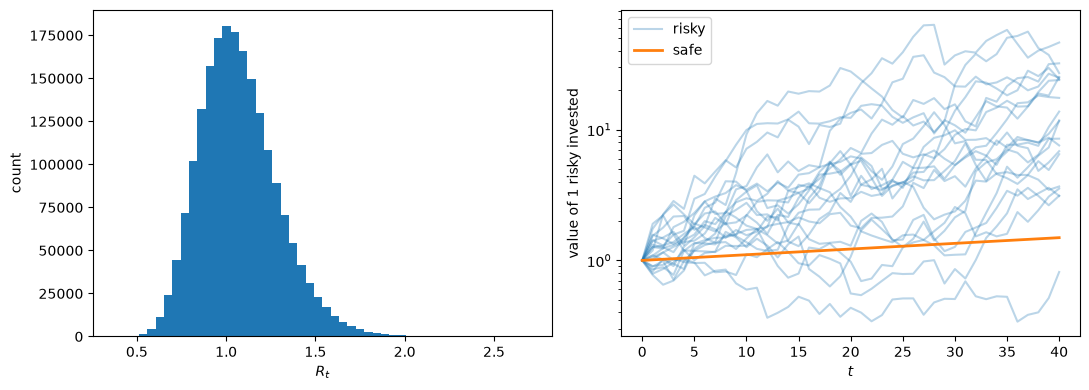

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# We plot a histogram of all the simulated gross returns
axes[0].hist(R.flatten(), bins=50)
axes[0].set_xlabel('$R_t$')
axes[0].set_ylabel('count')

# We compute the value of 1 invested in the risky asset, for 20 portfolios, and in the safe asset
value_risky = np.concatenate([np.ones((20, 1)), np.cumprod(R[:20], axis=1)], axis=1)
value_safe = np.exp(par.r * np.arange(par.T + 1))

# We plot both, on a logarithmic scale so the paths stay comparable
for i in range(20):
    axes[1].plot(value_risky[i], color='C0', alpha=0.3, label='risky' if i == 0 else None)
axes[1].plot(value_safe, color='C1', lw=2, label='safe')
axes[1].set_yscale('log')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('value of 1 risky invested')
# We add a legend to the second plot
axes[1].legend()
plt.tight_layout()
plt.show()

We can see that the histogram isn't symmetrical, as it is slightly right-skewed. This implies that 

Almost all of the 20 risky asset portfolios end up having a higher value than the safe asset. Theres only 1 portfolio that winds up having a lesser value than the safe asset in the last period, which is the only period that our investor cares about. When looking at a long time period such as this one, most of the bad draws get evened out by more good draws, which is why the risky asset mosly outperformes the safe asset

## Question 2

### 3.2.1

In [38]:
# We run the simulator once with the default (baseline) rule, reusing the returns from Question 1
model.simulate(R=R)

print(model.sim.W.shape)
print(model.sim.theta.shape)

(50000, 41)
(50000, 41)


### 3.2.2

In [39]:
import pandas as pd

# We set up the two extreme rules, with no transaction costs
rules = {
    'Delta=0': PortfolioModelClass(tau=0.0, Delta=0.0),
    'Delta=1': PortfolioModelClass(tau=0.0, Delta=1.0),
}

# We simulate both on the exact same drawn returns
for m in rules.values():
    m.simulate(R=R)

# We collect the six numbers for each rule in one table
rows = []
for name, m in rules.items():
    rows.append({'rule': name, **m.summary()})

pd.DataFrame(rows)

,rule,trades,distance,mean WT,median WT,10th pct WT,E[u(WT)]
0,Delta=0,39.0,0.039395,5.043602,4.081492,1.793667,-0.067829
1,Delta=1,0.0,0.191138,8.975620,4.447803,1.485479,-0.076690


As expected, when $\Delta=1$, there are 0 trades, as $\theta_t-\theta^*<1$ and therefore $\theta_t-\theta^*<\Delta$ for $0<\theta_t<1$

### 3.2.3

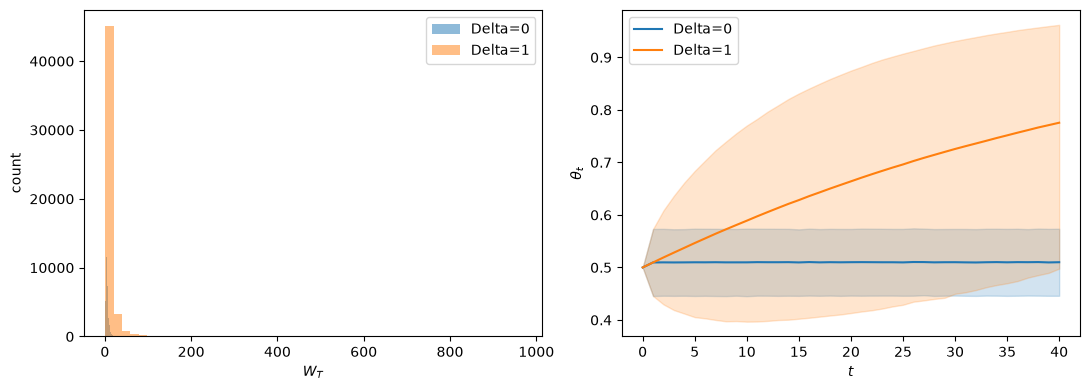

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# We plot a histogram of terminal wealth for both rules
for name, m in rules.items():
    axes[0].hist(m.sim.W[:, -1], bins=50, alpha=0.5, label=name)
axes[0].set_xlabel('$W_T$')
axes[0].set_ylabel('count')
axes[0].legend()

# We plot the mean risky share over time, with a shaded 10th-90th percentile band
t = np.arange(par.T + 1)
for name, m in rules.items():
    mean_theta = m.sim.theta.mean(axis=0)
    p10 = np.percentile(m.sim.theta, 10, axis=0)
    p90 = np.percentile(m.sim.theta, 90, axis=0)

    line, = axes[1].plot(t, mean_theta, label=name)
    axes[1].fill_between(t, p10, p90, color=line.get_color(), alpha=0.2)

axes[1].set_xlabel('$t$')
axes[1].set_ylabel(r'$\theta_t$')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2.4

We can see that the mean share of $\theta_t$, represented by the orange line, grows steadily throughout the timeperiod. The 10th percentile almost has the same share of $\theta_t$ as the portofolio of $\Delta=1$ where $\theta_t=0.5$, and the 90th percentile has a far higher share , at around $\theta_t=0.95$.

In the case where $\Delta$=1 (where 0 trades are being made), the investor keeps the same portfolio that she has at $t_0$ where she has an equal amount of units in each asset, implying $\theta_t=1-\theta_t=0.5$ at $t_0$. This means that the change in the share of $\theta_t$ purely comes from the fluctuations in the risky asset. If $\theta_t>1-\theta_t$ then the risky asset has cumulatively outperformed the safe asset, and if $\theta_t<1-\theta_t$ the safe asset has cumulatively outperformed the risky asset. 
$\theta_t>0.5$ in the vast majority of cases, which means that it is cumulatively outperforming the safe asset. 

We can also see the same underlying cause in the graph in 3.1.3, where the simulation of the 20 portfolios shows almost the same tendency as the graph in 3.2.3. That is, the risky asset mostly outperforms the safe asset - implying that $\theta_t>1-\theta_t$.

## Question 3

### 3.3.1

In [41]:
Deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1]

# We simulate every band width with the same transaction cost and the same drawn returns
rows = []
for Delta in Deltas:
    m = PortfolioModelClass(tau=0.01, Delta=Delta)
    m.simulate(R=R)
    rows.append({'Delta': Delta, **m.summary()})

df_delta = pd.DataFrame(rows).set_index('Delta')
df_delta

,trades,distance,mean WT,median WT,10th pct WT,E[u(WT)]
Delta,,,,,,
0.000,39.00000,0.039395,4.962427,4.018396,1.768274,-0.069934
0.025,24.52346,0.039974,4.974622,4.018379,1.769181,-0.069745
0.050,14.33342,0.042948,5.015482,4.035755,1.767369,-0.069505
0.075,8.79048,0.047986,5.073901,4.047645,1.765500,-0.069347
0.100,5.86028,0.054052,5.145886,4.060641,1.759388,-0.069460
0.150,3.15190,0.068029,5.328542,4.104170,1.735272,-0.069950
0.200,1.95026,0.083468,5.559645,4.186286,1.679246,-0.070944
0.300,0.90548,0.117972,6.195680,4.341368,1.536125,-0.073406
1.000,0.00000,0.191138,8.975620,4.447803,1.485479,-0.076690


### 3.3.2

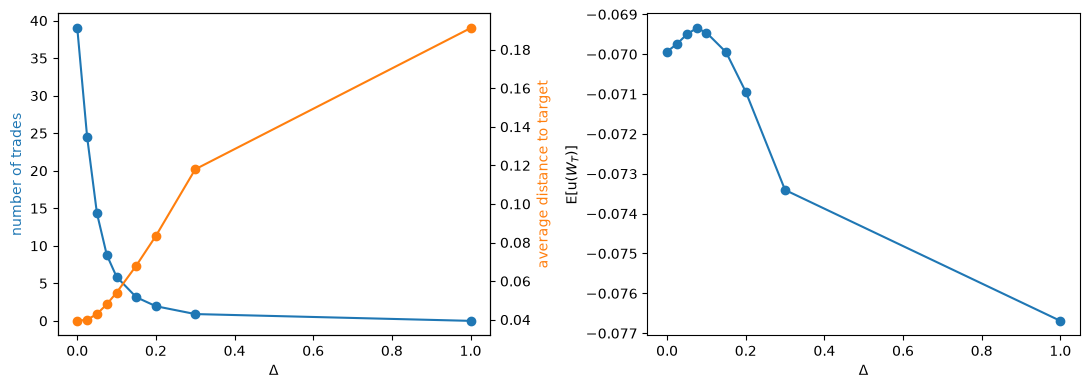

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# We plot the number of trades and the average distance to target against Delta, on two y-axes
ax2 = axes[0].twinx()
axes[0].plot(df_delta.index, df_delta['trades'], color='C0', marker='o', label='trades')
ax2.plot(df_delta.index, df_delta['distance'], color='C1', marker='o', label='distance')
axes[0].set_xlabel(r'$\Delta$')
axes[0].set_ylabel('number of trades', color='C0')
ax2.set_ylabel('average distance to target', color='C1')

# We plot expected utility against Delta
axes[1].plot(df_delta.index, df_delta['E[u(WT)]'], marker='o')
axes[1].set_xlabel(r'$\Delta$')
axes[1].set_ylabel('E[u($W_T$)]')

plt.tight_layout()
plt.show()

### 3.3.3

In [43]:
# We use the method idxmax to find the index of the maximum expected utility, and max to find the maximum value itself
best_Delta = df_delta['E[u(WT)]'].idxmax()
best_EU = df_delta['E[u(WT)]'].max()

# We compare the best Delta with the two extremes from Question 2
print(f'best Delta = {best_Delta}, E[u(WT)] = {best_EU:.4f}')
print(f'improvement over Delta=0: {best_EU - df_delta.loc[0, "E[u(WT)]"]:.4f}')
print(f'improvement over Delta=1: {best_EU - df_delta.loc[1, "E[u(WT)]"]:.4f}')

best Delta = 0.075, E[u(WT)] = -0.0693
improvement over Delta=0: 0.0006
improvement over Delta=1: 0.0073


The best $\Delta$ in terms of the expected utility of the investor is 0.075 with $E[u(W_T)]=-0.0693$. This only  marginaly outperforms $\Delta=0$ by 0.0006, whereas it outperforms $\Delta=1$ by 0.0073

### 3.3.4

As $\Delta$ grows, so do the distance between $\theta_t$ and $\theta^*$, the mean of $W_T$ and the median of $W_T$. The number of trades and the 10th percentiles wealth fall as $\Delta$ grows, and when $\Delta>0.075$, the expected utility is diminishing for larger $\Delta$

When $\Delta$ is going from 0 to the best $\Delta$ (0.075), the number of trades change quite a bit - from 39 to right under 9. It makes sense that number of trades decrease as the no-trade band increases. The only other number that changes by a noteable amount is the difference between $\theta_t$ and $\theta^*$. Otherwise the numbers only change marginally 

If the different outcomes instead were ordered by the mean wealth, it would not be optimal to chose the same rule as above. We can reuse the above code to find the $\Delta$ that generates the highest mean wealth empirically. 

In [ ]:
#We want to find the Delta that maximizes the mean wealth at the end of the investment horizon, WT. We can do this by using the idxmax method to find the index of the maximum mean WT, and max to find the maximum value itself.
best_Delta_mean_WT = df_delta['mean WT'].idxmax()
print(f'best Delta for mean WT = {best_Delta_mean_WT}, mean WT = {df_delta.loc[best_Delta_mean_WT, "mean WT"]:.4f}')

best Delta for mean WT = 1.0, mean WT = 8.9756


The best $\Delta$ when we want to maximize the mean wealth is $\Delta=1$ - it is actually also the $\Delta$ that maximizes the median wealth. This means the we should change our rule if it was ranked by mean or median. 

The expected utility function reveals that we shouldn't just look at the median and mean to make our investment decision. Mean and median mostly look in the middle of the distrubition, and the expected utility looks at all the outcomes. 

$u(W) =\frac{W^{1−γ}}{1−γ}$ with $\gamma=3$ is concave, implying that there's diminishing marginal utility. $\gamma$ is an expression of the risk aversion of our investor, which is a factor that should be taken into account. $\gamma=3$ means that our investor is relatively risk averse, as she gets less utility even though the mean and median are higher. This implies that she cares more about the negative outcomes in terms of return rather than the positive outcomes. 